# Your Corpus vs USTC: Places Analysis

Compare printing places in your sphere editions corpus with top USTC printing cities (1470-1650)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Load Your Corpus Data

In [11]:
# Load your book data
books = pd.read_csv('full_book_data_feb_25.csv')

print("Corpus data loaded:")
print(f"  Total images: {len(books)}")
print(f"  Columns: {books.columns.tolist()}")
print(f"\nFirst few rows:")
print(books.head())

Corpus data loaded:
  Total images: 359
  Columns: ['book', 'label', 'bid', 'authors', 'publishers', 'printers', 'place', 'year', 'num_pages', 'year_interval', 'place_category']

First few rows:
                                                book  \
0  http://sphaera.mpiwg-berlin.mpg.de/id/item/83a...   
1  http://sphaera.mpiwg-berlin.mpg.de/id/item/8a2...   
2  http://sphaera.mpiwg-berlin.mpg.de/id/item/a09...   
3  http://sphaera.mpiwg-berlin.mpg.de/id/item/57c...   
4  http://sphaera.mpiwg-berlin.mpg.de/id/item/55b...   

                                               label   bid  \
0     Opus sphericum magistri Ioannis de Sacro busto  2118   
1  Introductorium compendiosum in Tractatum spere...  1860   
2                         Sphaera Iani de Sacrobusto  1772   
3  Quaestiones novae, in libellum de Sphaera Ioha...  2117   
4                                      Sphaera Mundi  1865   

                                   authors  \
0                  Sacrobosco, Johannes de   
1  

## 2. Load USTC Top Places Data

In [12]:
# Load USTC top 5 places per decade
ustc_top_places = pd.read_csv('../ustc_data/top_5_places_by_decade.csv')

print("USTC Top 5 Places by Decade:")
print(ustc_top_places.head(10))

# Aggregate editions by place (across all decades)
ustc_editions_by_place = ustc_top_places.groupby('place')['edition_count'].sum().sort_values(ascending=False)

print(f"\n\nTotal unique places in USTC top 5: {len(ustc_editions_by_place)}")
print(f"\nTop 15 USTC places:")
print(ustc_editions_by_place.head(15))

USTC Top 5 Places by Decade:
      decade  rank     place  edition_count
0  1470-1479     1  Deventer           1477
1  1470-1479     2    Lübeck           1476
2  1470-1479     3   Venezia           1475
3  1470-1479     4    Napoli           1474
4  1470-1479     5      Roma           1471
5  1480-1489     1   Leipzig           1487
6  1480-1489     2  Augsburg           1485
7  1480-1489     3    Milano           1480
8  1480-1489     4      Roma            577
9  1480-1489     5      Rome            500


Total unique places in USTC top 5: 27

Top 15 USTC places:
place
Milan         121346
Deventer       87959
Leipzig        83141
Toulouse       80307
Brescia        80051
Antwerp        76725
Strasbourg     70950
Lyon           68242
Roma           63766
Salamanca      33347
Paris          29441
Basel          25124
London         23128
Venezia        15634
Leiden         15484
Name: edition_count, dtype: int64


## 3. Analyze Your Corpus by Place

In [13]:
# Count unique books per place in your corpus
books_per_place = books.groupby('place')['book'].nunique()
books_per_place = books_per_place.sort_values(ascending=False)

print(f"Your corpus:")
print(f"  Total unique places: {len(books_per_place)}")
print(f"  Total images: {len(books)}")

print(f"\nTop 15 places in your corpus:")
print(books_per_place.head(15))

Your corpus:
  Total unique places: 43
  Total images: 359

Top 15 places in your corpus:
place
Venice              70
Paris               69
Wittenberg          48
Antwerp             22
Leipzig             19
Frankfurt (Main)    17
Lyon                16
Cologne             15
London              13
Rome                 6
Strasbourg           5
Seville              5
Leiden               4
Milan                3
Saint Gervais        3
Name: book, dtype: int64


## 4. Find Common Places

In [14]:
# Get top 10 from each dataset
corpus_top_10 = books_per_place.head(10)
ustc_top_10 = ustc_editions_by_place.head(10)

print("Top 10 in your corpus:")
print(corpus_top_10)

print("\n" + "="*60)
print("\nTop 10 in USTC:")
print(ustc_top_10)

# Find common places
common_places = set(corpus_top_10.index) & set(ustc_top_10.index)
print(f"\n" + "="*60)
print(f"\n🎯 COMMON PLACES (in both top 10 lists): {common_places}")

only_corpus = set(corpus_top_10.index) - set(ustc_top_10.index)
only_ustc = set(ustc_top_10.index) - set(corpus_top_10.index)

print(f"\n📍 Only in your corpus top 10: {only_corpus}")
print(f"📍 Only in USTC top 10: {only_ustc}")

Top 10 in your corpus:
place
Venice              70
Paris               69
Wittenberg          48
Antwerp             22
Leipzig             19
Frankfurt (Main)    17
Lyon                16
Cologne             15
London              13
Rome                 6
Name: book, dtype: int64


Top 10 in USTC:
place
Milan         121346
Deventer       87959
Leipzig        83141
Toulouse       80307
Brescia        80051
Antwerp        76725
Strasbourg     70950
Lyon           68242
Roma           63766
Salamanca      33347
Name: edition_count, dtype: int64


🎯 COMMON PLACES (in both top 10 lists): {'Lyon', 'Leipzig', 'Antwerp'}

📍 Only in your corpus top 10: {'London', 'Venice', 'Wittenberg', 'Rome', 'Paris', 'Cologne', 'Frankfurt (Main)'}
📍 Only in USTC top 10: {'Strasbourg', 'Toulouse', 'Deventer', 'Salamanca', 'Brescia', 'Milan', 'Roma'}


## 5. Create Comparison Dataframe

In [15]:
# Create comparison dataframe with all places from both top 10 lists
all_places = set(corpus_top_10.index) | set(ustc_top_10.index)
comparison_data = []

for place in sorted(all_places):
    corpus_count = corpus_top_10.get(place, 0)
    ustc_count = ustc_top_10.get(place, 0)
    
    comparison_data.append({
        'place': place,
        'corpus_books': corpus_count,
        'ustc_editions': ustc_count
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('corpus_books', ascending=False)

print("Combined Top Places (from both datasets):")
print(comparison_df)

Combined Top Places (from both datasets):
               place  corpus_books  ustc_editions
15            Venice            70              0
9              Paris            69              0
16        Wittenberg            48              0
0            Antwerp            22          76725
5            Leipzig            19          83141
4   Frankfurt (Main)            17              0
7               Lyon            16          68242
2            Cologne            15              0
6             London            13              0
11              Rome             6              0
1            Brescia             0          80051
3           Deventer             0          87959
10              Roma             0          63766
12         Salamanca             0          33347
13        Strasbourg             0          70950
14          Toulouse             0          80307
8              Milan             0         121346


## 6. Dual-Axis Comparison Plot

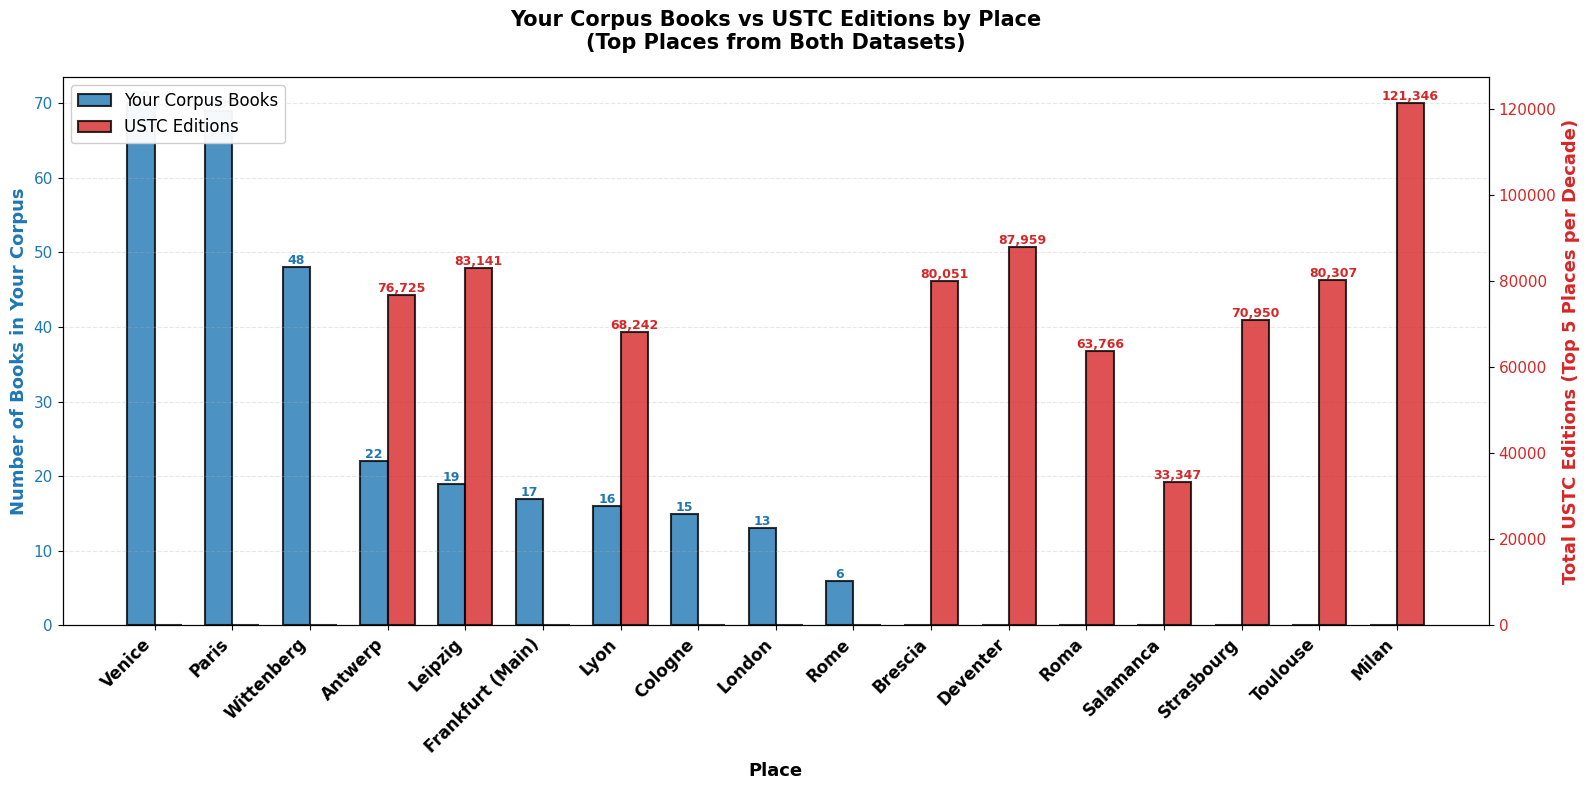

✅ Places comparison plot created!


In [16]:
# Create dual-axis bar chart for places
fig, ax1 = plt.subplots(figsize=(16, 8))

# X-axis positions
x_pos = np.arange(len(comparison_df))
width = 0.35

# ===== LEFT Y-AXIS: Your Corpus Books =====
color_corpus = 'tab:blue'
ax1.set_xlabel('Place', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Books in Your Corpus', color=color_corpus, fontsize=13, fontweight='bold')

bars1 = ax1.bar(x_pos - width/2, comparison_df['corpus_books'].values, width,
                label='Your Corpus Books', color=color_corpus, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color_corpus, labelsize=11)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels on corpus bars
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9, color=color_corpus, fontweight='bold')

# ===== RIGHT Y-AXIS: USTC Editions =====
ax2 = ax1.twinx()
color_ustc = 'tab:red'
ax2.set_ylabel('Total USTC Editions (Top 5 Places per Decade)', color=color_ustc, fontsize=13, fontweight='bold')

bars2 = ax2.bar(x_pos + width/2, comparison_df['ustc_editions'].values, width,
                label='USTC Editions', color=color_ustc, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.tick_params(axis='y', labelcolor=color_ustc, labelsize=11)

# Add value labels on USTC bars
for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=9, color=color_ustc, fontweight='bold')

# Set x-axis labels
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_df['place'].values, rotation=45, ha='right', fontsize=12, fontweight='bold')

# Title and legends
plt.title('Your Corpus Books vs USTC Editions by Place\n(Top Places from Both Datasets)', 
          fontsize=15, fontweight='bold', pad=20)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12, framealpha=0.95)

fig.tight_layout()
plt.show()

print("✅ Places comparison plot created!")

## 7. Summary Statistics

In [17]:
print("="*80)
print("PLACES ANALYSIS SUMMARY")
print("="*80)

print(f"\n📊 YOUR CORPUS:")
print(f"  Total unique places: {len(books_per_place)}")
print(f"  Top place: {books_per_place.index[0]} ({books_per_place.values[0]} books)")
print(f"  Average books per place: {books_per_place.mean():.2f}")
print(f"  Median: {books_per_place.median():.0f}")

print(f"\n📊 USTC DATA (Top 5 per Decade):")
print(f"  Total unique places: {len(ustc_editions_by_place)}")
print(f"  Top place: {ustc_editions_by_place.index[0]} ({ustc_editions_by_place.values[0]:.0f} editions)")
print(f"  Average editions per place: {ustc_editions_by_place.mean():.0f}")
print(f"  Median: {ustc_editions_by_place.median():.0f}")

print(f"\n🎯 COMMON PLACES (in both top 10):")
if common_places:
    for place in sorted(common_places):
        corpus_val = corpus_top_10.get(place, 0)
        ustc_val = ustc_top_10.get(place, 0)
        ratio = ustc_val / corpus_val if corpus_val > 0 else 0
        print(f"  {place:20} Corpus: {corpus_val:3} | USTC: {ustc_val:8,.0f} | Ratio: 1:{ratio:.0f}")
else:
    print(f"  No places appear in both top 10 lists")

print(f"\n📍 ONLY IN YOUR CORPUS (top 10): {only_corpus if only_corpus else 'None'}")
print(f"📍 ONLY IN USTC (top 10): {only_ustc if only_ustc else 'None'}")

print("\n" + "="*80)

PLACES ANALYSIS SUMMARY

📊 YOUR CORPUS:
  Total unique places: 43
  Top place: Venice (70 books)
  Average books per place: 8.35
  Median: 2

📊 USTC DATA (Top 5 per Decade):
  Total unique places: 27
  Top place: Milan (121346 editions)
  Average editions per place: 34057
  Median: 15634

🎯 COMMON PLACES (in both top 10):
  Antwerp              Corpus:  22 | USTC:   76,725 | Ratio: 1:3488
  Leipzig              Corpus:  19 | USTC:   83,141 | Ratio: 1:4376
  Lyon                 Corpus:  16 | USTC:   68,242 | Ratio: 1:4265

📍 ONLY IN YOUR CORPUS (top 10): {'London', 'Venice', 'Wittenberg', 'Rome', 'Paris', 'Cologne', 'Frankfurt (Main)'}
📍 ONLY IN USTC (top 10): {'Strasbourg', 'Toulouse', 'Deventer', 'Salamanca', 'Brescia', 'Milan', 'Roma'}



## 8. Optional: Save the Plot

In [18]:
# fig.savefig('../corpus_vs_ustc_places.png', dpi=300, bbox_inches='tight')
# print("✅ Plot saved as corpus_vs_ustc_places.png")

## 9. Key Analysis: Are YOUR cities in the LARGE USTC cities?

This answers: Which of your important cities are also major European printing centers?

In [19]:
# Get top N places from USTC
N = 20  # Top 20 USTC places
ustc_top_n = ustc_editions_by_place.head(N)

print("="*80)
print(f"TOP {N} LARGEST PRINTING CITIES IN EUROPE (USTC)")
print("="*80)
print(f"{'Rank':<5} {'Place':<25} {'Total Editions':>15}")
print("-"*80)
for i, (place, count) in enumerate(ustc_top_n.items(), 1):
    in_corpus = '✓ IN YOUR CORPUS' if place in books_per_place.index else '✗ NOT IN YOUR CORPUS'
    print(f"{i:<5} {place:<25} {count:>15,.0f}  {in_corpus}")

TOP 20 LARGEST PRINTING CITIES IN EUROPE (USTC)
Rank  Place                      Total Editions
--------------------------------------------------------------------------------
1     Milan                             121,346  ✓ IN YOUR CORPUS
2     Deventer                           87,959  ✗ NOT IN YOUR CORPUS
3     Leipzig                            83,141  ✓ IN YOUR CORPUS
4     Toulouse                           80,307  ✗ NOT IN YOUR CORPUS
5     Brescia                            80,051  ✗ NOT IN YOUR CORPUS
6     Antwerp                            76,725  ✓ IN YOUR CORPUS
7     Strasbourg                         70,950  ✓ IN YOUR CORPUS
8     Lyon                               68,242  ✓ IN YOUR CORPUS
9     Roma                               63,766  ✗ NOT IN YOUR CORPUS
10    Salamanca                          33,347  ✓ IN YOUR CORPUS
11    Paris                              29,441  ✓ IN YOUR CORPUS
12    Basel                              25,124  ✓ IN YOUR CORPUS
13    London   

## 10. Which LARGE USTC cities are MISSING from your corpus?

These are major European printing centers that don't appear in your dataset at all.

In [20]:
# Find USTC top 20 that are NOT in your corpus at all
ustc_top_20 = ustc_editions_by_place.head(20)
missing_places = set(ustc_top_20.index) - set(books_per_place.index)

print("="*80)
print(f"LARGE USTC CITIES (Top 20) MISSING FROM YOUR CORPUS")
print("="*80)
if missing_places:
    print(f"\n⚠️  You have NO books from these major European printing centers:")
    missing_sorted = sorted([(place, ustc_top_20[place]) for place in missing_places], 
                           key=lambda x: x[1], reverse=True)
    for place, count in missing_sorted:
        print(f"  • {place:<25} {count:>12,.0f} editions in USTC")
else:
    print("\n✓ All top 20 USTC cities appear in your corpus!")

print("\n" + "="*80)
print(f"\nSummary:")
print(f"  Missing cities from top 20 USTC: {len(missing_places)}")
print(f"  Total editions lost: {sum(ustc_top_20[place] for place in missing_places):,.0f}")

LARGE USTC CITIES (Top 20) MISSING FROM YOUR CORPUS

⚠️  You have NO books from these major European printing centers:
  • Deventer                        87,959 editions in USTC
  • Toulouse                        80,307 editions in USTC
  • Brescia                         80,051 editions in USTC
  • Roma                            63,766 editions in USTC
  • Venezia                         15,634 editions in USTC
  • Amsterdam                       11,943 editions in USTC
  • Frankfurt                        7,785 editions in USTC
  • Milano                           4,736 editions in USTC
  • Köln                             4,714 editions in USTC
  • Augsburg                         3,014 editions in USTC


Summary:
  Missing cities from top 20 USTC: 10
  Total editions lost: 359,909


## 11. Are YOUR cities in the major USTC list?

This shows: Of the places you sampled from, how many are also major printing centers?

In [21]:
# For each place in your corpus, check if it's in USTC top N
print("="*80)
print(f"YOUR CORPUS PLACES: Are they in USTC top {N}?")
print("="*80)
print(f"\n{'Place':<25} {'Your Books':>12} {'USTC Rank':>15} {'USTC Editions':>15}")
print("-"*80)

in_ustc_top_n = 0
not_in_ustc_top_n = 0

for place, count in books_per_place.items():
    if place in ustc_top_n.index:
        rank = list(ustc_top_n.index).index(place) + 1
        ustc_count = ustc_top_n[place]
        print(f"{place:<25} {count:>12} {'#' + str(rank):>15} {ustc_count:>15,.0f}")
        in_ustc_top_n += 1
    else:
        not_in_ustc_top_n += 1

print("-"*80)
print(f"\nSummary of your {len(books_per_place)} places:")
print(f"  In USTC top {N}: {in_ustc_top_n} places")
print(f"  NOT in USTC top {N}: {not_in_ustc_top_n} places")
print(f"\n✓ Coverage: {100*in_ustc_top_n/len(books_per_place):.1f}% of your places are major European centers")

YOUR CORPUS PLACES: Are they in USTC top 20?

Place                       Your Books       USTC Rank   USTC Editions
--------------------------------------------------------------------------------
Paris                               69             #11          29,441
Antwerp                             22              #6          76,725
Leipzig                             19              #3          83,141
Lyon                                16              #8          68,242
London                              13             #13          23,128
Strasbourg                           5              #7          70,950
Leiden                               4             #15          15,484
Milan                                3              #1         121,346
Salamanca                            3             #10          33,347
Basel                                2             #12          25,124
--------------------------------------------------------------------------------

Summary of